<a href="https://colab.research.google.com/github/aabyyaann/scikit-learn-Cookbook/blob/main/Chapter10_Clustering_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 10 - Clustering Techniques

Notebook ini merangkum materi **Chapter 10: Clustering Techniques** dari buku **scikit-learn Cookbook**.  
Fokus utama bab ini adalah mempelajari beberapa teknik clustering dalam machine learning tanpa label (unsupervised learning), mulai dari **K-Means**, **Hierarchical Clustering**, **DBSCAN**, evaluasi cluster, hingga clustering data berdimensi tinggi menggunakan **PCA** dan **Gaussian Mixture Models (GMM)**.

## Topik yang dibahas
1. Pengantar clustering
2. K-Means clustering
3. Hierarchical clustering
4. Density-based clustering dengan DBSCAN
5. Evaluasi cluster
6. Memilih algoritma clustering yang tepat
7. Advanced clustering dengan PCA dan GMM
8. Latihan praktis clustering

## 1. Pengertian Clustering

Clustering adalah teknik **unsupervised learning** yang bertujuan untuk mengelompokkan data berdasarkan kemiripan karakteristik.  
Berbeda dengan supervised learning, pada clustering **tidak ada label target**. Model akan mencoba menemukan struktur alami dari data.

Contoh penggunaan clustering:
- segmentasi pelanggan
- pengelompokan dokumen
- analisis perilaku pengguna
- deteksi pola pada data biologis
- pengelompokan citra atau sensor data

Pada bab ini, kita akan menggunakan beberapa dataset dari `scikit-learn` seperti **Iris**, **make_blobs**, dan **make_moons**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style("whitegrid")
np.random.seed(42)

print("Library untuk Chapter 10 berhasil diimport.")

Library untuk Chapter 10 berhasil diimport.


## 2. Menyiapkan Dataset

Kita akan mulai dengan dataset **Iris**, salah satu dataset paling populer dalam machine learning.  
Dataset ini memiliki:
- 150 sampel
- 4 fitur numerik
- 3 kelas bunga (hanya digunakan nanti untuk evaluasi, bukan saat training clustering)

Karena clustering sensitif terhadap skala, kita akan melakukan **standardisasi** terlebih dahulu.

In [2]:
iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

df_iris = pd.DataFrame(X, columns=feature_names)
df_iris["target"] = y
df_iris["species"] = df_iris["target"].map({
    0: target_names[0],
    1: target_names[1],
    2: target_names[2]
})

print("Shape dataset:", df_iris.shape)
df_iris.head()

Shape dataset: (150, 6)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
df_iris.info()
print("\nJumlah missing values:")
print(df_iris.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Jumlah missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64


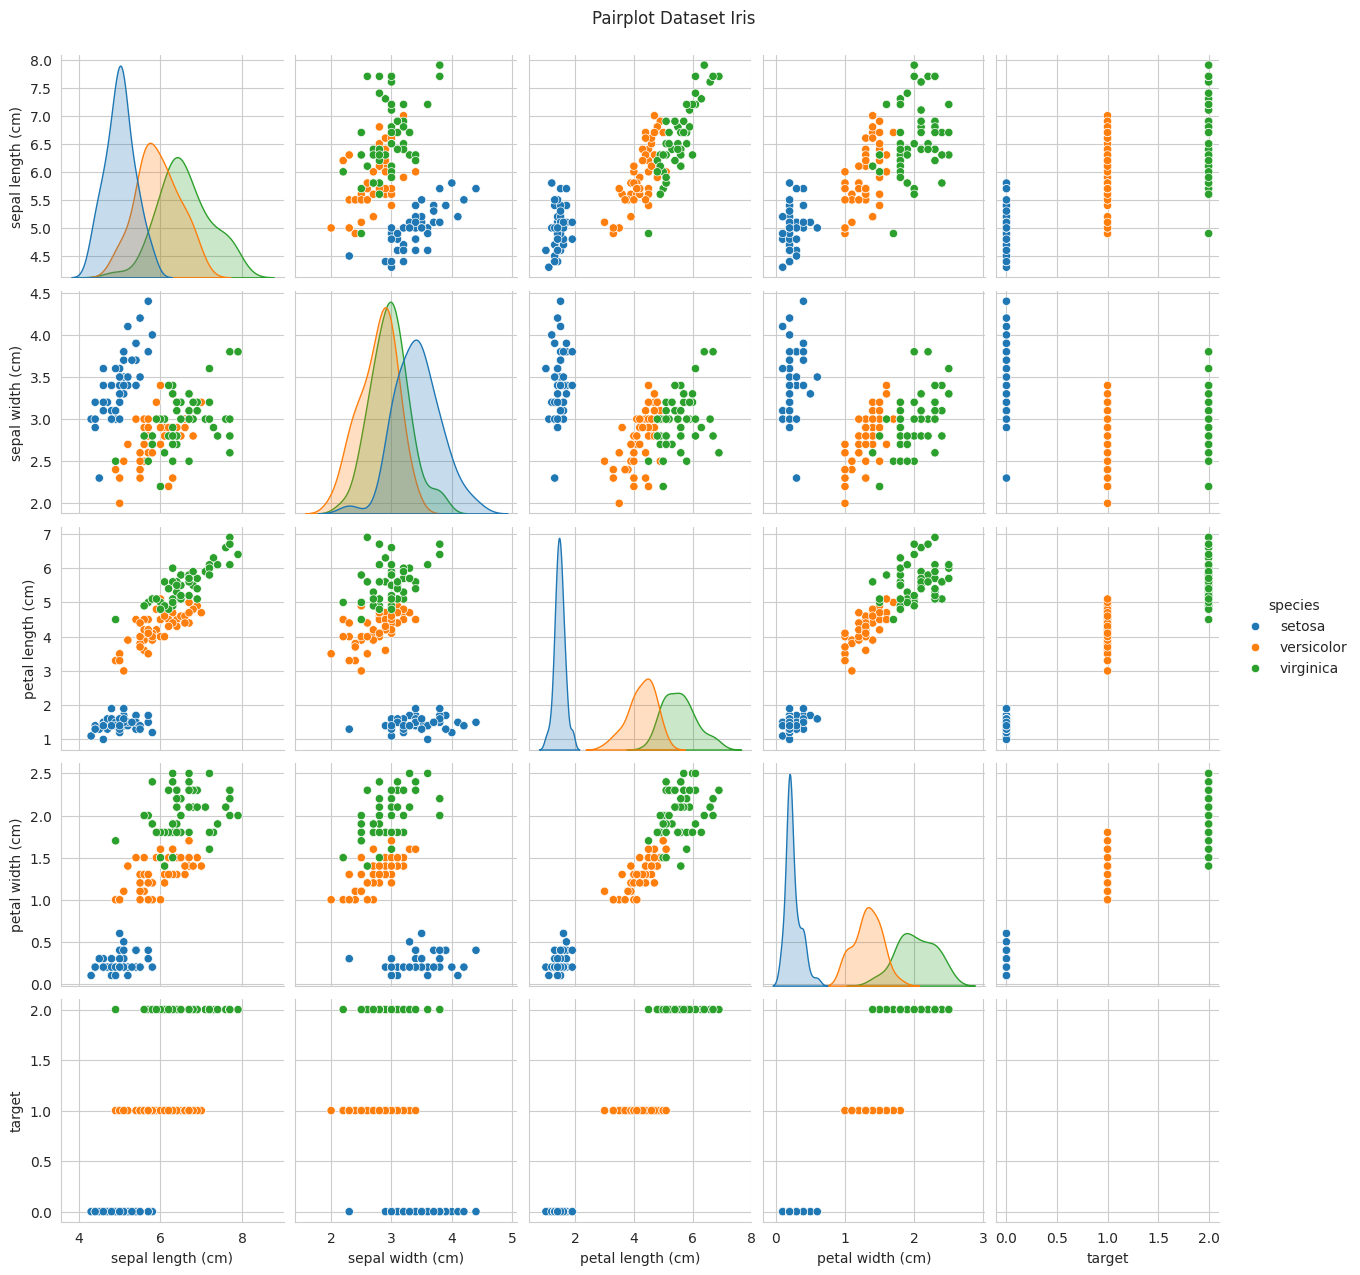

In [4]:
sns.pairplot(df_iris, hue="species")
plt.suptitle("Pairplot Dataset Iris", y=1.02)
plt.show()

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Shape setelah scaling:", X_scaled.shape)
print("Rata-rata fitur (mendekati 0):")
print(np.round(X_scaled.mean(axis=0), 4))

Shape setelah scaling: (150, 4)
Rata-rata fitur (mendekati 0):
[-0. -0. -0. -0.]


## 3. K-Means Clustering

K-Means adalah algoritma clustering yang membagi data ke dalam **K cluster** berdasarkan jarak ke pusat cluster (**centroid**).  
Proses sederhananya:
1. Tentukan jumlah cluster `k`
2. Inisialisasi centroid
3. Assign setiap titik ke centroid terdekat
4. Update centroid berdasarkan rata-rata anggota cluster
5. Ulangi sampai konvergen

Kelebihan:
- cepat
- sederhana
- cocok untuk cluster berbentuk bulat

Kekurangan:
- harus menentukan jumlah cluster dari awal
- sensitif terhadap outlier
- kurang cocok untuk cluster dengan bentuk kompleks

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)

clusters_kmeans = kmeans.labels_
centroids = kmeans.cluster_centers_

print("Label cluster K-Means:")
print(clusters_kmeans[:20])

print("\nCentroid cluster:")
print(pd.DataFrame(centroids, columns=feature_names))

Label cluster K-Means:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Centroid cluster:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0          -0.050220         -0.883376           0.347738          0.281527
1          -1.014579          0.853263          -1.304987         -1.254893
2           1.135970          0.088422           0.996155          1.017526


In [7]:
df_iris["kmeans_cluster"] = clusters_kmeans
df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species,kmeans_cluster
0,5.1,3.5,1.4,0.2,0,setosa,1
1,4.9,3.0,1.4,0.2,0,setosa,1
2,4.7,3.2,1.3,0.2,0,setosa,1
3,4.6,3.1,1.5,0.2,0,setosa,1
4,5.0,3.6,1.4,0.2,0,setosa,1


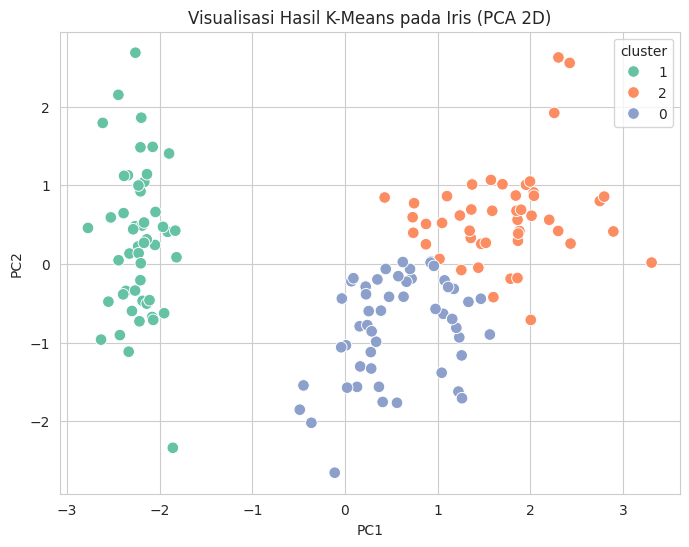

In [8]:
pca_2d = PCA(n_components=2)
X_pca = pca_2d.fit_transform(X_scaled)

df_plot = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
df_plot["cluster"] = clusters_kmeans.astype(str)
df_plot["species"] = df_iris["species"]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_plot, x="PC1", y="PC2", hue="cluster", palette="Set2", s=70)
plt.title("Visualisasi Hasil K-Means pada Iris (PCA 2D)")
plt.show()

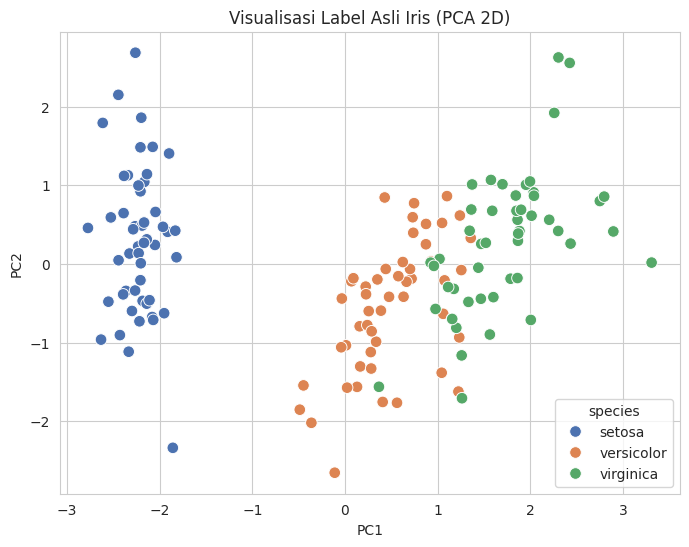

In [9]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_plot, x="PC1", y="PC2", hue="species", palette="deep", s=70)
plt.title("Visualisasi Label Asli Iris (PCA 2D)")
plt.show()

## 4. Evaluasi Hasil K-Means

Karena clustering bersifat unsupervised, evaluasi biasanya dilakukan dengan:
- **Silhouette Score** → mengukur seberapa baik pemisahan cluster
- **Adjusted Rand Index (ARI)** → membandingkan cluster dengan label asli jika tersedia
- **Inertia** → total jarak kuadrat titik ke centroid

Interpretasi:
- Silhouette semakin mendekati 1 → cluster semakin baik
- ARI semakin mendekati 1 → hasil clustering semakin mirip label asli
- Inertia kecil → titik lebih dekat ke centroid

In [10]:
sil_kmeans = silhouette_score(X_scaled, clusters_kmeans)
ari_kmeans = adjusted_rand_score(y, clusters_kmeans)

print("Evaluasi K-Means")
print("Silhouette Score :", round(sil_kmeans, 4))
print("Adjusted Rand Index :", round(ari_kmeans, 4))
print("Inertia :", round(kmeans.inertia_, 4))

Evaluasi K-Means
Silhouette Score : 0.4599
Adjusted Rand Index : 0.6201
Inertia : 139.8205


## 5. Menentukan Jumlah Cluster dengan Elbow Method

Salah satu tantangan utama K-Means adalah menentukan nilai `k`.  
Metode yang sering digunakan adalah **Elbow Method**, yaitu melihat perubahan nilai **inertia** untuk beberapa nilai `k`.

Ide dasarnya:
- jika penurunan inertia mulai melandai, titik tersebut bisa menjadi kandidat jumlah cluster optimal.

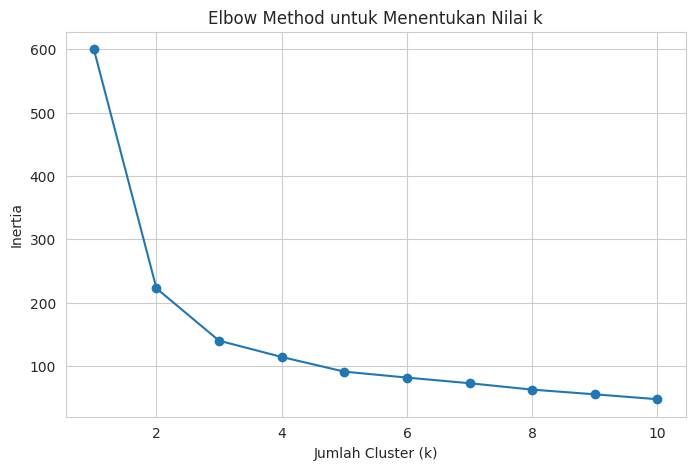

In [11]:
inertias = []
k_values = range(1, 11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method untuk Menentukan Nilai k")
plt.show()

## 6. Hierarchical Clustering

Hierarchical clustering membentuk struktur cluster secara bertahap.  
Ada dua pendekatan utama:
- **Agglomerative**: mulai dari tiap titik sebagai cluster sendiri, lalu digabung bertahap
- **Divisive**: mulai dari satu cluster besar, lalu dipecah

Pada scikit-learn, yang umum digunakan adalah **Agglomerative Clustering**.

Kelebihan:
- tidak perlu centroid
- bisa divisualisasikan dengan dendrogram
- fleksibel untuk bentuk cluster tertentu

Kekurangan:
- lebih mahal secara komputasi dibanding K-Means
- hasil sensitif terhadap linkage method

In [12]:
agg = AgglomerativeClustering(n_clusters=3)
clusters_agg = agg.fit_predict(X_scaled)

df_iris["agg_cluster"] = clusters_agg

print("Label cluster Agglomerative:")
print(clusters_agg[:20])

Label cluster Agglomerative:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


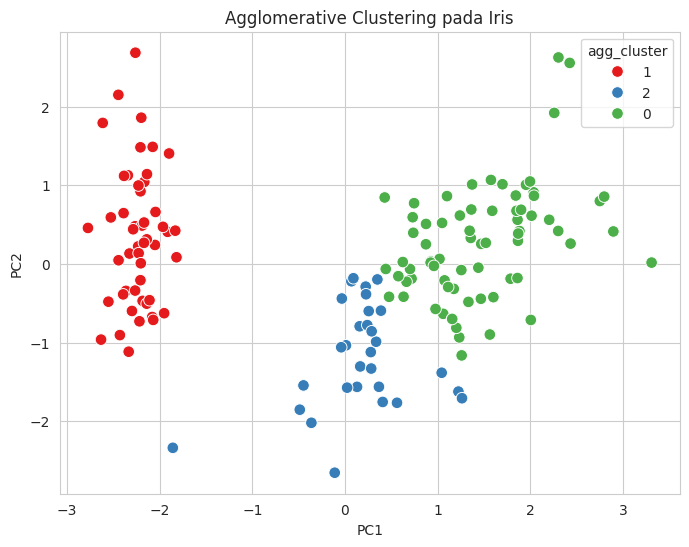

In [13]:
df_plot["agg_cluster"] = clusters_agg.astype(str)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_plot, x="PC1", y="PC2", hue="agg_cluster", palette="Set1", s=70)
plt.title("Agglomerative Clustering pada Iris")
plt.show()

In [14]:
sil_agg = silhouette_score(X_scaled, clusters_agg)
ari_agg = adjusted_rand_score(y, clusters_agg)

print("Evaluasi Agglomerative Clustering")
print("Silhouette Score :", round(sil_agg, 4))
print("Adjusted Rand Index :", round(ari_agg, 4))

Evaluasi Agglomerative Clustering
Silhouette Score : 0.4467
Adjusted Rand Index : 0.6153


## 7. Dendrogram

Dendrogram adalah visualisasi struktur hierarchical clustering.  
Grafik ini menunjukkan urutan penggabungan cluster dari level bawah ke atas.  
Semakin tinggi cabang yang digabung, semakin besar jarak antar cluster yang digabungkan.

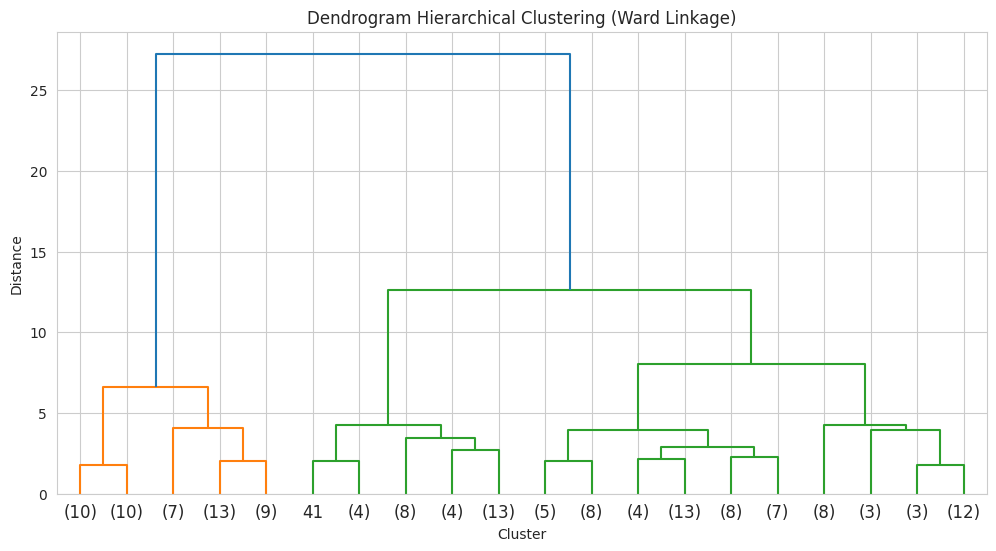

In [15]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))
dendrogram(linked, truncate_mode="lastp", p=20)
plt.title("Dendrogram Hierarchical Clustering (Ward Linkage)")
plt.xlabel("Cluster")
plt.ylabel("Distance")
plt.show()

## 8. DBSCAN

DBSCAN (**Density-Based Spatial Clustering of Applications with Noise**) adalah algoritma clustering berbasis kepadatan.  
DBSCAN mengelompokkan titik-titik yang berada di area padat dan dapat menandai titik yang jarang muncul sebagai **noise** atau outlier.

Parameter utama:
- `eps` → radius tetangga
- `min_samples` → minimum jumlah titik untuk membentuk area padat

Kelebihan:
- tidak perlu menentukan jumlah cluster
- bisa menemukan cluster berbentuk tidak beraturan
- bisa mendeteksi noise

Kekurangan:
- sensitif terhadap pemilihan `eps`
- sulit jika kepadatan cluster sangat bervariasi

In [16]:
dbscan = DBSCAN(eps=0.8, min_samples=5)
clusters_dbscan = dbscan.fit_predict(X_scaled)

df_iris["dbscan_cluster"] = clusters_dbscan

print("Label unik hasil DBSCAN:", np.unique(clusters_dbscan))
print("Jumlah anggota tiap label:")
print(pd.Series(clusters_dbscan).value_counts().sort_index())

Label unik hasil DBSCAN: [-1  0  1]
Jumlah anggota tiap label:
-1     4
 0    49
 1    97
Name: count, dtype: int64


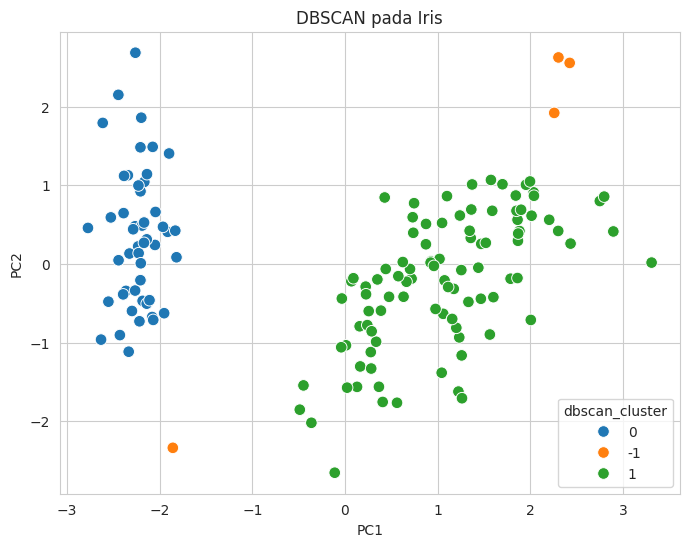

In [17]:
df_plot["dbscan_cluster"] = clusters_dbscan.astype(str)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_plot, x="PC1", y="PC2", hue="dbscan_cluster", palette="tab10", s=70)
plt.title("DBSCAN pada Iris")
plt.show()

In [18]:
# Silhouette score hanya valid jika jumlah cluster lebih dari 1
unique_dbscan = np.unique(clusters_dbscan)

if len(unique_dbscan) > 1 and len(unique_dbscan) < len(X_scaled):
    sil_dbscan = silhouette_score(X_scaled, clusters_dbscan)
    ari_dbscan = adjusted_rand_score(y, clusters_dbscan)
    print("Evaluasi DBSCAN")
    print("Silhouette Score :", round(sil_dbscan, 4))
    print("Adjusted Rand Index :", round(ari_dbscan, 4))
else:
    print("DBSCAN tidak menghasilkan cluster yang cukup untuk dihitung silhouette score.")

Evaluasi DBSCAN
Silhouette Score : 0.5217
Adjusted Rand Index : 0.5518


## 9. Membandingkan K-Means, Agglomerative, dan DBSCAN

Agar lebih mudah memahami perbedaan ketiga algoritma, kita bandingkan hasil evaluasinya:
- **K-Means**
- **Agglomerative Clustering**
- **DBSCAN**

Perlu diingat bahwa nilai evaluasi dapat berubah tergantung dataset, preprocessing, dan parameter model.

In [19]:
results = []

results.append({
    "Model": "K-Means",
    "Silhouette": silhouette_score(X_scaled, clusters_kmeans),
    "ARI": adjusted_rand_score(y, clusters_kmeans)
})

results.append({
    "Model": "Agglomerative",
    "Silhouette": silhouette_score(X_scaled, clusters_agg),
    "ARI": adjusted_rand_score(y, clusters_agg)
})

if len(np.unique(clusters_dbscan)) > 1 and len(np.unique(clusters_dbscan)) < len(X_scaled):
    results.append({
        "Model": "DBSCAN",
        "Silhouette": silhouette_score(X_scaled, clusters_dbscan),
        "ARI": adjusted_rand_score(y, clusters_dbscan)
    })

comparison = pd.DataFrame(results)
comparison

,Model,Silhouette,ARI
0,K-Means,0.459948,0.620135
1,Agglomerative,0.446689,0.615323
2,DBSCAN,0.521697,0.551755


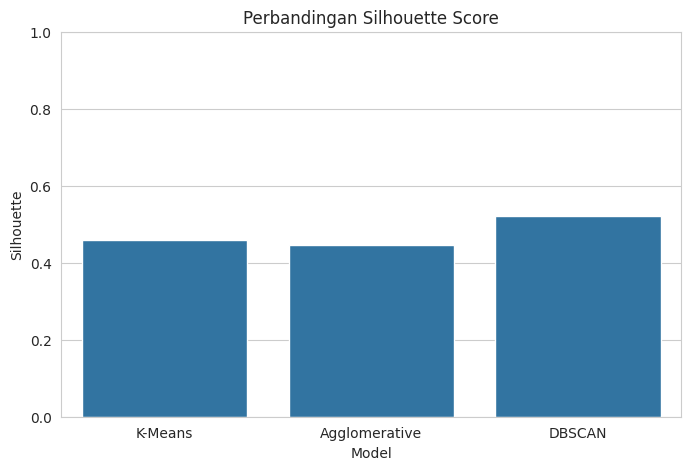

In [20]:
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison, x="Model", y="Silhouette")
plt.title("Perbandingan Silhouette Score")
plt.ylim(0, 1)
plt.show()

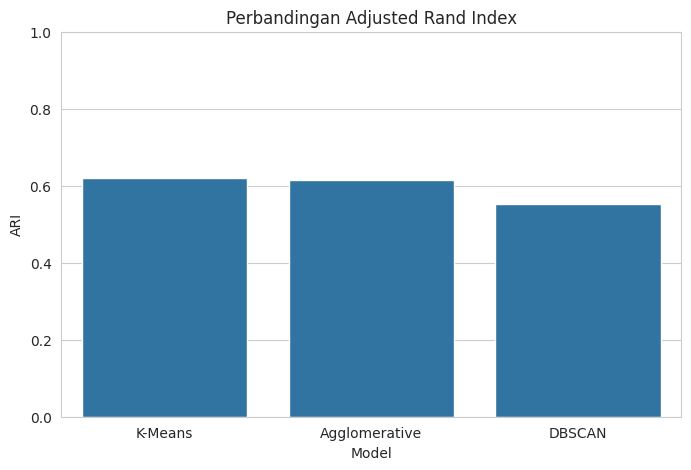

In [21]:
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison, x="Model", y="ARI")
plt.title("Perbandingan Adjusted Rand Index")
plt.ylim(0, 1)
plt.show()

## 10. Clustering pada Data Sintetis: K-Means vs DBSCAN

Sekarang kita gunakan data buatan agar terlihat lebih jelas kapan K-Means dan DBSCAN bekerja dengan baik.  
Kita akan membuat:
1. dataset **blob** → cocok untuk K-Means
2. dataset **moons** → bentuk cluster tidak linear, lebih cocok untuk DBSCAN

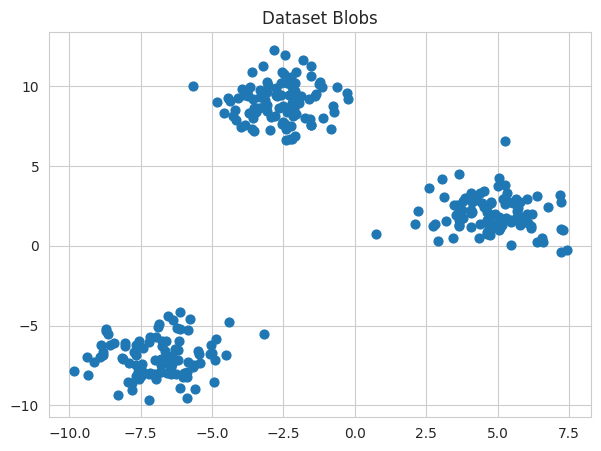

In [22]:
X_blobs, y_blobs = make_blobs(n_samples=300, centers=3, cluster_std=1.2, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], s=40)
plt.title("Dataset Blobs")
plt.show()

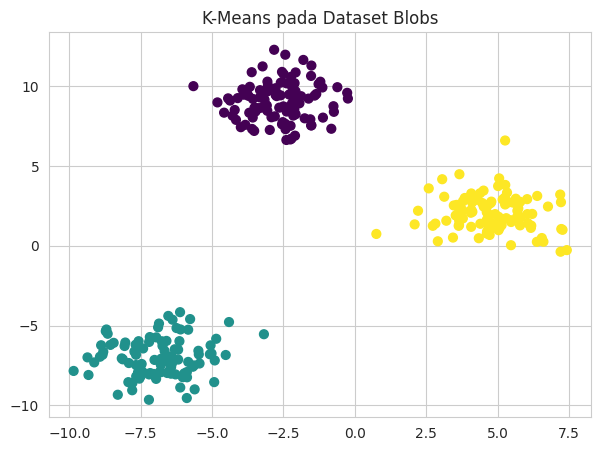

Silhouette Score: 0.8181


In [23]:
kmeans_blobs = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_blobs = kmeans_blobs.fit_predict(X_blobs)

plt.figure(figsize=(7, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_blobs, cmap="viridis", s=40)
plt.title("K-Means pada Dataset Blobs")
plt.show()

print("Silhouette Score:", round(silhouette_score(X_blobs, labels_blobs), 4))

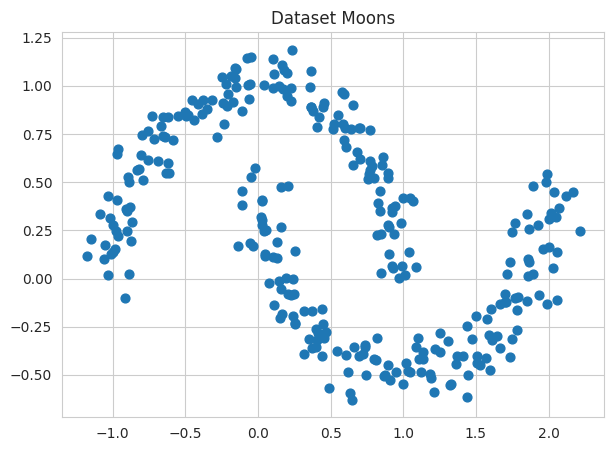

In [24]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.08, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], s=40)
plt.title("Dataset Moons")
plt.show()

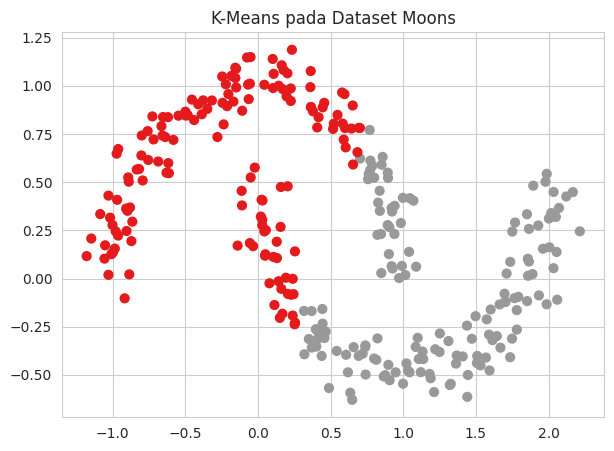

Silhouette Score K-Means: 0.4836


In [25]:
kmeans_moons = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_kmeans_moons = kmeans_moons.fit_predict(X_moons)

plt.figure(figsize=(7, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_kmeans_moons, cmap="Set1", s=40)
plt.title("K-Means pada Dataset Moons")
plt.show()

print("Silhouette Score K-Means:", round(silhouette_score(X_moons, labels_kmeans_moons), 4))

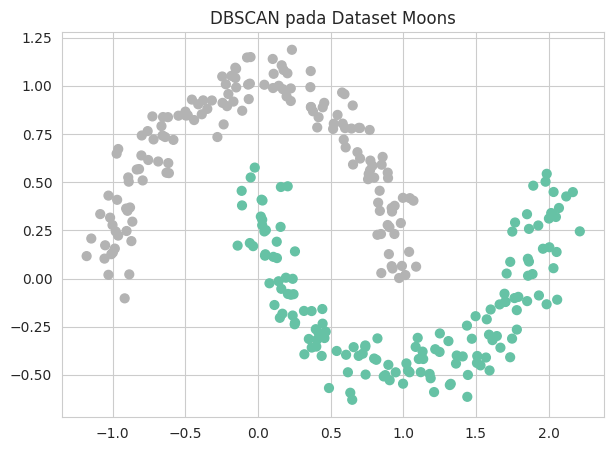

Silhouette Score DBSCAN: 0.3273


In [26]:
dbscan_moons = DBSCAN(eps=0.2, min_samples=5)
labels_dbscan_moons = dbscan_moons.fit_predict(X_moons)

plt.figure(figsize=(7, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_dbscan_moons, cmap="Set2", s=40)
plt.title("DBSCAN pada Dataset Moons")
plt.show()

if len(np.unique(labels_dbscan_moons)) > 1:
    print("Silhouette Score DBSCAN:", round(silhouette_score(X_moons, labels_dbscan_moons), 4))

## 11. Memilih Algoritma Clustering yang Tepat

Tidak ada satu algoritma clustering yang selalu terbaik untuk semua kasus.  
Pemilihan algoritma tergantung pada karakteristik data:

### Gunakan K-Means jika:
- jumlah cluster kira-kira diketahui
- cluster berbentuk bulat / kompak
- data cukup besar dan butuh algoritma cepat

### Gunakan Agglomerative jika:
- ingin melihat struktur cluster bertingkat
- dataset tidak terlalu besar
- ingin interpretasi melalui dendrogram

### Gunakan DBSCAN jika:
- cluster berbentuk tidak beraturan
- ingin mendeteksi noise / outlier
- tidak ingin menentukan jumlah cluster di awal

## 12. Advanced Clustering: PCA + Gaussian Mixture Model (GMM)

Untuk data berdimensi tinggi, sering kali kita melakukan reduksi dimensi terlebih dahulu menggunakan **PCA**.  
Setelah itu, kita bisa menggunakan **Gaussian Mixture Model (GMM)** untuk clustering yang lebih fleksibel dibanding K-Means.

Perbedaan utama:
- **K-Means** mengasumsikan cluster berbentuk bulat dengan centroid
- **GMM** memodelkan data sebagai campuran distribusi Gaussian, sehingga lebih fleksibel

In [27]:
pca = PCA(n_components=2, random_state=42)
X_pca2 = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
print(np.round(pca.explained_variance_ratio_, 4))
print("Total explained variance:", round(pca.explained_variance_ratio_.sum(), 4))

Explained variance ratio:
[0.7296 0.2285]
Total explained variance: 0.9581


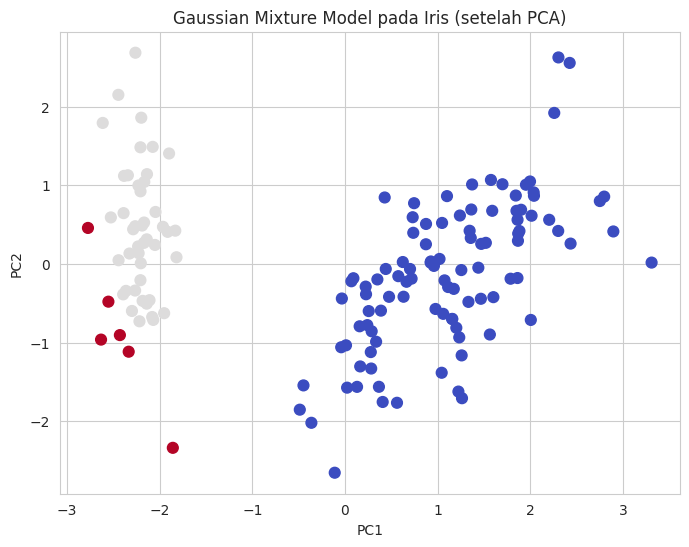

In [28]:
gmm = GaussianMixture(n_components=3, random_state=42)
gmm_labels = gmm.fit_predict(X_pca2)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=gmm_labels, cmap="coolwarm", s=60)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Gaussian Mixture Model pada Iris (setelah PCA)")
plt.show()

In [29]:
sil_gmm = silhouette_score(X_pca2, gmm_labels)
ari_gmm = adjusted_rand_score(y, gmm_labels)

print("Evaluasi GMM")
print("Silhouette Score :", round(sil_gmm, 4))
print("Adjusted Rand Index :", round(ari_gmm, 4))

Evaluasi GMM
Silhouette Score : 0.4677
Adjusted Rand Index : 0.5149


## 13. Praktik 1 - K-Means pada Iris

Latihan pertama adalah menerapkan K-Means pada dataset Iris, lalu mengevaluasi hasilnya.

In [30]:
exercise_kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
exercise_labels = exercise_kmeans.fit_predict(X_scaled)

print("Silhouette Score:", round(silhouette_score(X_scaled, exercise_labels), 4))
print("ARI:", round(adjusted_rand_score(y, exercise_labels), 4))

Silhouette Score: 0.4599
ARI: 0.6201


## 14. Praktik 2 - Membandingkan K-Means dan DBSCAN pada Moon Dataset

Tujuan latihan ini adalah melihat bahwa:
- K-Means bagus untuk cluster bulat
- DBSCAN lebih baik untuk cluster non-linear seperti moon dataset

In [31]:
compare_results = []

compare_results.append({
    "Model": "K-Means on moons",
    "Silhouette": silhouette_score(X_moons, labels_kmeans_moons)
})

if len(np.unique(labels_dbscan_moons)) > 1:
    compare_results.append({
        "Model": "DBSCAN on moons",
        "Silhouette": silhouette_score(X_moons, labels_dbscan_moons)
    })

pd.DataFrame(compare_results)

,Model,Silhouette
0,K-Means on moons,0.483590
1,DBSCAN on moons,0.327256


## 15. Praktik 3 - PCA + GMM pada Data Berdimensi Tinggi

Pada latihan ini, kita menggabungkan:
- **PCA** untuk mereduksi dimensi
- **GMM** untuk clustering

Pendekatan ini berguna jika:
- jumlah fitur cukup banyak
- visualisasi cluster dibutuhkan
- struktur data tidak selalu cocok untuk K-Means

In [32]:
summary_gmm = pd.DataFrame({
    "PC1": X_pca2[:, 0],
    "PC2": X_pca2[:, 1],
    "GMM_Cluster": gmm_labels,
    "True_Label": y
})

summary_gmm.head()

,PC1,PC2,GMM_Cluster,True_Label
0,-2.264703,0.480027,1,0
1,-2.080961,-0.674134,1,0
2,-2.364229,-0.341908,1,0
3,-2.299384,-0.597395,1,0
4,-2.389842,0.646835,1,0


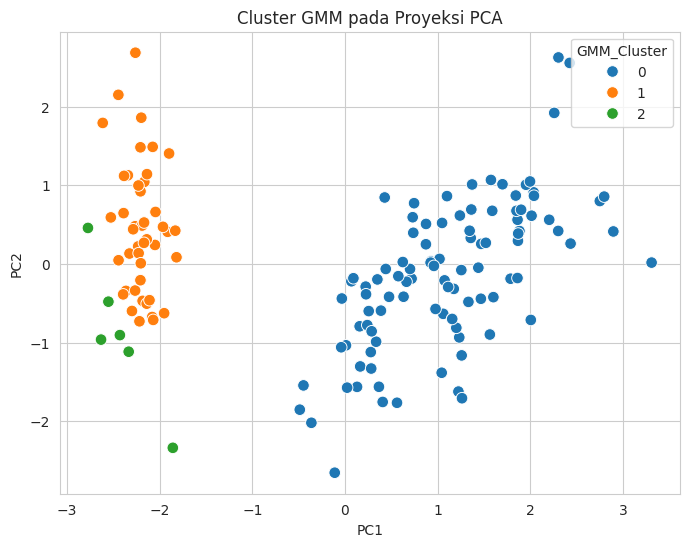

In [33]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=summary_gmm, x="PC1", y="PC2", hue="GMM_Cluster", palette="tab10", s=70)
plt.title("Cluster GMM pada Proyeksi PCA")
plt.show()

## 16. Ringkasan Hasil Clustering

Dari eksperimen pada chapter ini, kita mempelajari beberapa hal penting:

1. **K-Means** bekerja baik untuk data yang memiliki cluster kompak dan relatif bulat.
2. **Agglomerative Clustering** berguna untuk melihat struktur hirarki antar data.
3. **DBSCAN** sangat berguna untuk cluster berbentuk tidak beraturan dan untuk mendeteksi noise.
4. **Silhouette Score** membantu mengevaluasi kualitas cluster secara internal.
5. **ARI** membantu membandingkan cluster dengan label asli jika tersedia.
6. **PCA + GMM** adalah kombinasi yang baik untuk data berdimensi tinggi dan visualisasi cluster.

Dengan demikian, pemilihan algoritma clustering harus disesuaikan dengan:
- bentuk data
- jumlah cluster yang diharapkan
- keberadaan noise
- tujuan analisis

## 17. Kesimpulan Chapter 10

Chapter ini menunjukkan bahwa clustering bukan hanya tentang membagi data ke dalam kelompok, tetapi juga tentang memahami **struktur alami data**.  
Setiap algoritma memiliki asumsi dan karakteristik yang berbeda:

- **K-Means** cocok untuk cluster kompak
- **Agglomerative** cocok untuk analisis hirarki
- **DBSCAN** cocok untuk cluster non-linear dan deteksi noise
- **GMM** memberi pendekatan probabilistik yang lebih fleksibel

Melalui evaluasi dan visualisasi, kita bisa memilih metode clustering yang paling sesuai dengan permasalahan yang dihadapi.